# Step 1: 単目的ベイズ最適化 (Single-Objective BO)

BoTorch の基本的な使い方を理解する。

**ゴール:**
- サロゲートモデル（SingleTaskGP）と獲得関数（EI）の動作を理解
- 1D の可視化で BO ループの直感を掴む
- 2D テスト関数（Branin）で実践

**構成:**
1. 1D での BO の仕組み可視化
2. BO ループの実装
3. 2D Branin 関数での最適化

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.manual_seed(42)
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

## 1. 1D での BO の仕組みを可視化

まず 1D のテスト関数で、BO の各コンポーネントを目で見て理解する。

- **黒い線**: 真の目的関数（普通は未知。BOはこれを少ない評価で最適化したい）
- **青い線**: GP サロゲートモデルの予測（平均 ± 2σ）
- **赤い点**: これまでに評価した点
- **緑の線**: 獲得関数 EI（次にどこを評価すべきかを示す）

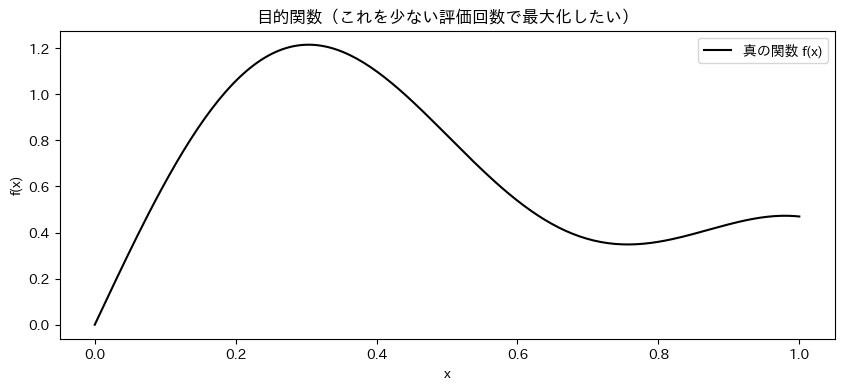

In [14]:
# 真の目的関数（未知として扱う）
# sin 波 + ちょっとした非線形性。最大化を目指す。
def true_function(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(3 * x) + 0.5 * torch.sin(7 * x)

# 可視化用の密なグリッド
X_plot = torch.linspace(0, 1, 200).unsqueeze(-1)
Y_plot = true_function(X_plot)

plt.plot(X_plot.numpy(), Y_plot.numpy(), "k-", label="真の関数 f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("目的関数（これを少ない評価回数で最大化したい）")
plt.show()

In [15]:
# 初期データ: ランダムに3点だけ評価
train_X = torch.tensor([[0.1], [0.5], [0.9]])
train_Y = true_function(train_X)

print(f"初期データ ({len(train_X)}点):")
for x, y in zip(train_X, train_Y):
    print(f"  x={x.item():.2f}, f(x)={y.item():.4f}")

初期データ (3点):
  x=0.10, f(x)=0.6176
  x=0.50, f(x)=0.8221
  x=0.90, f(x)=0.4358


### GP サロゲートモデルのフィッティング

BoTorch の `SingleTaskGP` は GPyTorch の GP をラップしたもの。
`fit_gpytorch_mll` でカーネルのハイパーパラメータ（lengthscale, outputscale, noise）を最適化する。

In [16]:
# SingleTaskGP: BoTorch の標準的なサロゲートモデル
# BoTorch 0.17 では RBF カーネルを使用
gp = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)

# フィットされたハイパーパラメータを確認
print("カーネルハイパーパラメータ:")
print(f"  lengthscale = {gp.covar_module.lengthscale.item():.4f}")
print(f"  noise       = {gp.likelihood.noise.item():.6f}")

カーネルハイパーパラメータ:
  lengthscale = 0.1385
  noise       = 0.006716


/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/3457780205.py:3: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  gp = SingleTaskGP(train_X, train_Y)


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


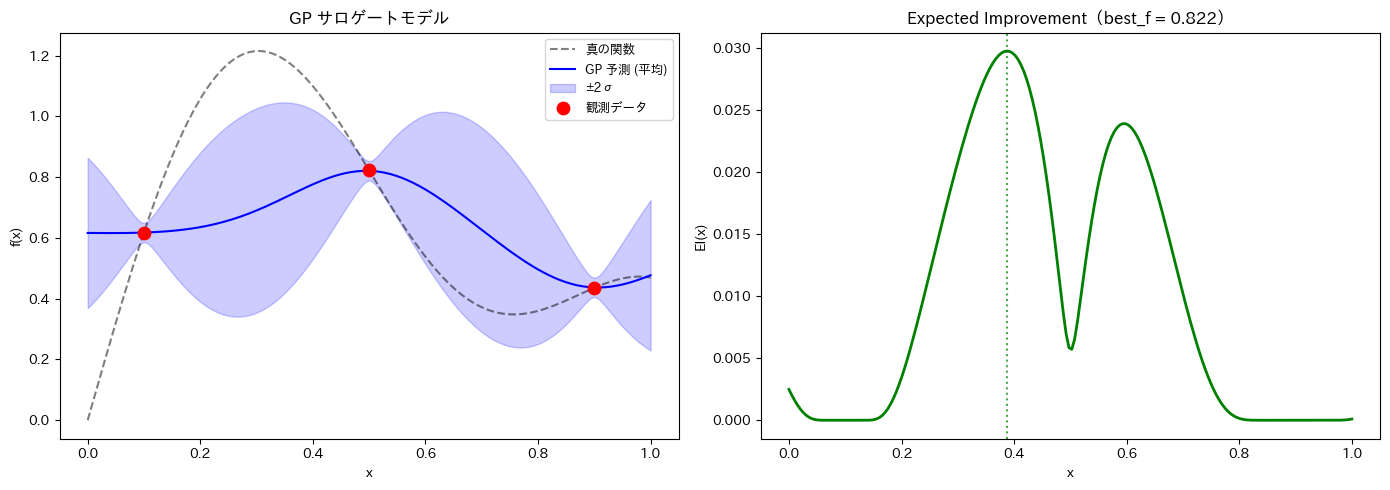

→ 次に評価すべき点: x = 0.3869


In [17]:
# GP の予測を可視化
gp.eval()
with torch.no_grad():
    posterior = gp.posterior(X_plot)
    mean = posterior.mean.squeeze()
    std = posterior.variance.squeeze().sqrt()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: GP の予測
ax1.plot(X_plot, Y_plot, "k--", alpha=0.5, label="真の関数")
ax1.plot(X_plot, mean, "b-", label="GP 予測 (平均)")
ax1.fill_between(X_plot.squeeze(), mean - 2 * std, mean + 2 * std, alpha=0.2, color="blue", label="±2σ")
ax1.scatter(train_X, train_Y, c="red", s=80, zorder=5, label="観測データ")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.legend(fontsize=9)
ax1.set_title("GP サロゲートモデル")

# 右: EI 獲得関数
best_f = train_Y.max()
ei = ExpectedImprovement(model=gp, best_f=best_f)
with torch.no_grad():
    ei_values = ei(X_plot.unsqueeze(1))  # shape: (n, 1, d) → (n,)

ax2.plot(X_plot, ei_values, "g-", linewidth=2)
ax2.axvline(X_plot[ei_values.argmax()].item(), color="green", linestyle=":", alpha=0.7)
ax2.set_xlabel("x")
ax2.set_ylabel("EI(x)")
ax2.set_title(f"Expected Improvement（best_f = {best_f.item():.3f}）")

plt.tight_layout()
plt.show()

print(f"→ 次に評価すべき点: x = {X_plot[ei_values.argmax()].item():.4f}")

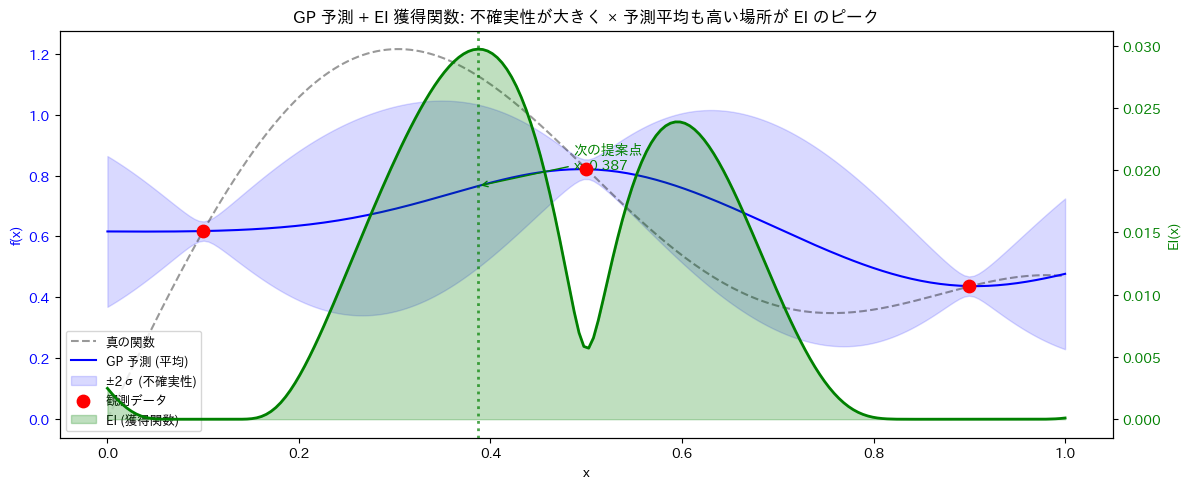

In [18]:
# GP 予測と EI を1つの図に重ねて表示
fig, ax1 = plt.subplots(figsize=(12, 5))

# GP 予測（左Y軸）
ax1.plot(X_plot, Y_plot, "k--", alpha=0.4, label="真の関数")
ax1.plot(X_plot, mean, "b-", label="GP 予測 (平均)")
ax1.fill_between(X_plot.squeeze(), mean - 2 * std, mean + 2 * std,
                 alpha=0.15, color="blue", label="±2σ (不確実性)")
ax1.scatter(train_X, train_Y, c="red", s=80, zorder=5, label="観測データ")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# EI（右Y軸）
ax2 = ax1.twinx()
ax2.fill_between(X_plot.squeeze(), 0, ei_values.numpy(), alpha=0.25, color="green", label="EI (獲得関数)")
ax2.plot(X_plot, ei_values, "g-", linewidth=2)
ax2.set_ylabel("EI(x)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

# EI 最大点に縦線
best_x = X_plot[ei_values.argmax()].item()
ax1.axvline(best_x, color="green", linestyle=":", alpha=0.7, linewidth=2)
ax1.annotate(f"次の提案点\nx={best_x:.3f}", xy=(best_x, mean[ei_values.argmax()]),
             xytext=(best_x + 0.1, mean.max().item()),
             arrowprops=dict(arrowstyle="->", color="green"), fontsize=10, color="green")

# 凡例を統合
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left", fontsize=9)

ax1.set_title("GP 予測 + EI 獲得関数: 不確実性が大きく × 予測平均も高い場所が EI のピーク")
plt.tight_layout()
plt.show()

## 2. BO ループの実装

BO の本質は以下のループ:

```
for each iteration:
    1. GP をフィット（サロゲートモデル更新）
    2. 獲得関数を最適化（次の候補点を選択）
    3. 候補点で真の関数を評価
    4. データに追加
```

`optimize_acqf` が獲得関数の最適化を担当する。内部で L-BFGS-B を使う。

In [19]:
def run_bo_1d(n_initial=3, n_iterations=10, seed=42):
    """1D ベイズ最適化ループ"""
    torch.manual_seed(seed)

    # 初期データ
    train_X = torch.rand(n_initial, 1)
    train_Y = true_function(train_X)

    bounds = torch.tensor([[0.0], [1.0]])  # x ∈ [0, 1]
    history = []  # 各イテレーションの記録

    for i in range(n_iterations):
        # 1. GP フィット
        gp = SingleTaskGP(train_X, train_Y)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)

        # 2. 獲得関数の最適化
        best_f = train_Y.max()
        ei = ExpectedImprovement(model=gp, best_f=best_f)
        candidate, acq_value = optimize_acqf(
            acq_function=ei,
            bounds=bounds,
            q=1,              # 1点ずつ提案
            num_restarts=5,   # 多点スタートで局所解を回避
            raw_samples=20,   # 初期点のランダムサンプル数
        )

        # 3. 真の関数を評価
        new_Y = true_function(candidate)

        # 記録
        history.append({
            "iteration": i + 1,
            "x": candidate.item(),
            "y": new_Y.item(),
            "best_so_far": max(best_f.item(), new_Y.item()),
            "model": gp,
        })

        # 4. データ更新
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, new_Y])

        print(f"  iter {i+1:2d}: x={candidate.item():.4f}, f(x)={new_Y.item():.4f}, best={train_Y.max().item():.4f}")

    return train_X, train_Y, history

print("BO ループ開始:")
train_X, train_Y, history = run_bo_1d()
print(f"\n最終結果: best f(x) = {train_Y.max().item():.4f} at x = {train_X[train_Y.argmax()].item():.4f}")

BO ループ開始:
  iter  1: x=0.1823, f(x)=0.9984, best=1.1349
  iter  2: x=0.3352, f(x)=1.2015, best=1.2015


/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/2438662303.py:14: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  gp = SingleTaskGP(train_X, train_Y)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/2438662303.py:14: InputDataWarning: The model i

  iter  3: x=0.3098, f(x)=1.2145, best=1.2145
  iter  4: x=0.3062, f(x)=1.2150, best=1.2150
  iter  5: x=0.3065, f(x)=1.2150, best=1.2150


/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/2438662303.py:14: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  gp = SingleTaskGP(train_X, train_Y)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/2438662303.py:14: InputDataWarning: The model i

  iter  6: x=0.0000, f(x)=0.0000, best=1.2150
  iter  7: x=0.2948, f(x)=1.2140, best=1.2150
  iter  8: x=0.2957, f(x)=1.2142, best=1.2150


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/2438662303.py:14: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  gp = SingleTaskGP(train_X, train_Y)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:

  iter  9: x=0.5933, f(x)=0.5543, best=1.2150
  iter 10: x=0.3001, f(x)=1.2149, best=1.2150

最終結果: best f(x) = 1.2150 at x = 0.3062


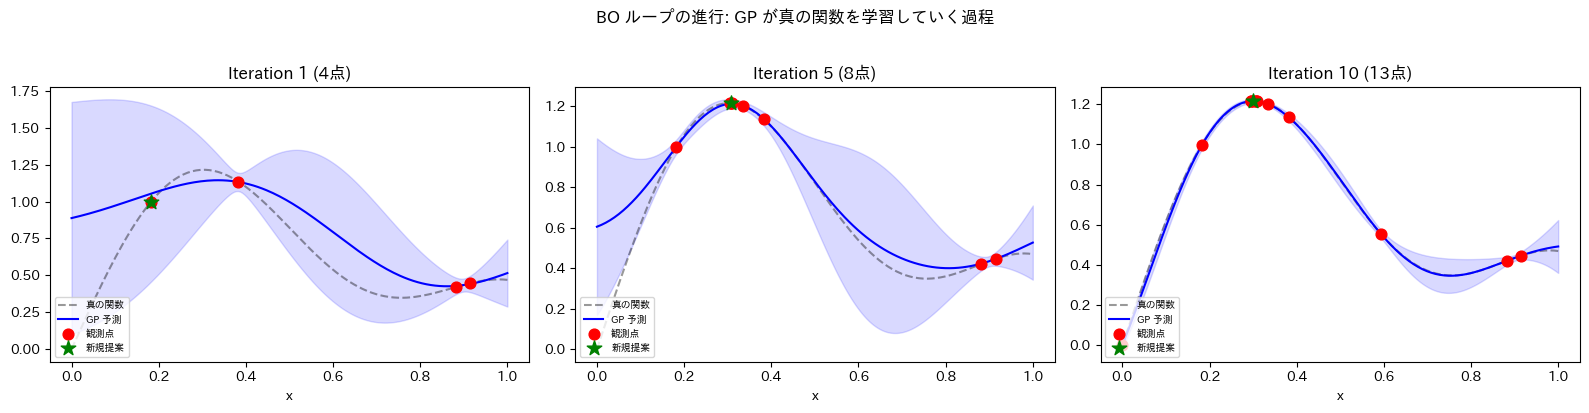

In [20]:
# BO の進行を可視化: 最初・中間・最終の3スナップショット
snapshots = [0, 4, 9]  # iteration 1, 5, 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, idx in zip(axes, snapshots):
    h = history[idx]
    gp = h["model"]
    gp.eval()

    n_data = 3 + idx + 1  # 初期3点 + idx+1点
    data_X = train_X[:n_data]
    data_Y = train_Y[:n_data]

    with torch.no_grad():
        posterior = gp.posterior(X_plot)
        mean = posterior.mean.squeeze()
        std = posterior.variance.squeeze().sqrt()

    ax.plot(X_plot, Y_plot, "k--", alpha=0.4, label="真の関数")
    ax.plot(X_plot, mean, "b-", label="GP 予測")
    ax.fill_between(X_plot.squeeze(), mean - 2 * std, mean + 2 * std, alpha=0.15, color="blue")
    ax.scatter(data_X, data_Y, c="red", s=60, zorder=5, label="観測点")
    ax.scatter(h["x"], h["y"], c="green", s=120, marker="*", zorder=6, label="新規提案")
    ax.set_title(f"Iteration {h['iteration']} ({n_data}点)")
    ax.set_xlabel("x")
    ax.legend(fontsize=7, loc="lower left")

plt.suptitle("BO ループの進行: GP が真の関数を学習していく過程", y=1.02)
plt.tight_layout()
plt.show()

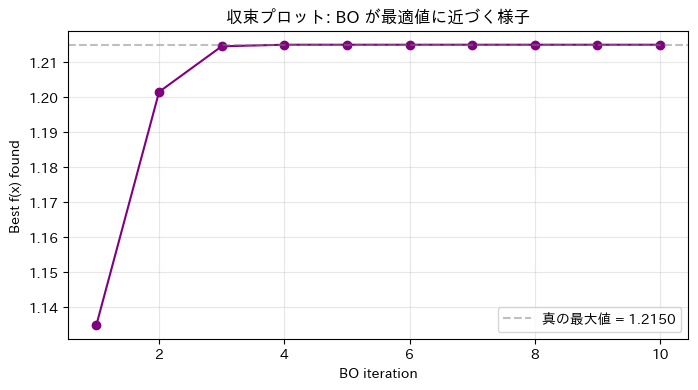

In [21]:
# best_f の収束プロット
best_values = [h["best_so_far"] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_values) + 1), best_values, "o-", color="purple")
plt.axhline(Y_plot.max().item(), color="gray", linestyle="--", alpha=0.5, label=f"真の最大値 = {Y_plot.max().item():.4f}")
plt.xlabel("BO iteration")
plt.ylabel("Best f(x) found")
plt.title("収束プロット: BO が最適値に近づく様子")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. 2D Branin 関数での最適化

Branin 関数は BO のベンチマークとして定番。BoTorch に組み込みのテスト関数を使う。

- 2変数 (x1, x2) → 1出力
- 3つのグローバル最小値を持つ（最小化問題）
- BoTorch は最大化が標準なので、符号を反転して `neg_branin` を使う

Branin 関数:
  入力次元: 2
  探索範囲: x1 ∈ [-5, 10], x2 ∈ [0, 15]
  最適値 (negated): 0.3979


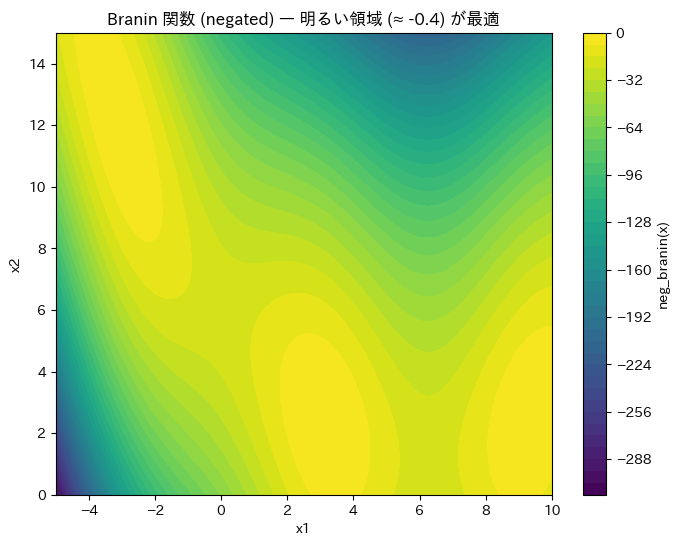


※ Branin は x1, x2 の複雑な非線形関数。x1+x2 の最大化ではない。
  3つのグローバル最適点を持つのが特徴。


In [25]:
from botorch.test_functions import Branin

branin = Branin(negate=True)  # negate=True で最大化問題に変換
bounds_2d = torch.stack([branin.bounds[0], branin.bounds[1]])  # [[-5, 0], [10, 15]]

print(f"Branin 関数:")
print(f"  入力次元: {branin.dim}")
print(f"  探索範囲: x1 ∈ [{bounds_2d[0,0]:.0f}, {bounds_2d[1,0]:.0f}], x2 ∈ [{bounds_2d[0,1]:.0f}, {bounds_2d[1,1]:.0f}]")
print(f"  最適値 (negated): {-branin.optimal_value:.4f}")

# Branin の地形を可視化（実際の探索範囲で描画）
n_grid = 100
x1 = torch.linspace(bounds_2d[0, 0], bounds_2d[1, 0], n_grid)
x2 = torch.linspace(bounds_2d[0, 1], bounds_2d[1, 1], n_grid)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
X_grid = torch.stack([X1.flatten(), X2.flatten()], dim=-1)
Y_grid = branin(X_grid).reshape(n_grid, n_grid)

plt.figure(figsize=(8, 6))
plt.contourf(X1.numpy(), X2.numpy(), Y_grid.numpy(), levels=50, cmap="viridis")
plt.colorbar(label="neg_branin(x)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Branin 関数 (negated) — 明るい領域 (≈ -0.4) が最適")
plt.show()

print("\n※ Branin は x1, x2 の複雑な非線形関数。x1+x2 の最大化ではない。")
print("  3つのグローバル最適点を持つのが特徴。")

In [28]:
def run_bo_2d(objective, bounds, n_initial=5, n_iterations=20, seed=0):
    """2D ベイズ最適化ループ（提案順を記録）"""
    torch.manual_seed(seed)

    # 初期データ: ランダムサンプリング
    train_X = torch.rand(n_initial, bounds.shape[1])
    train_Y = objective(train_X).unsqueeze(-1)
    history_2d = []

    for i in range(n_iterations):
        # GP フィット
        gp = SingleTaskGP(train_X, train_Y)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)

        # EI 最適化
        ei = ExpectedImprovement(model=gp, best_f=train_Y.max())
        candidate, _ = optimize_acqf(
            acq_function=ei,
            bounds=bounds,
            q=1,
            num_restarts=10,
            raw_samples=50,
        )

        # 評価 & データ更新
        new_Y = objective(candidate).unsqueeze(-1)
        train_X = torch.cat([train_X, candidate])
        train_Y = torch.cat([train_Y, new_Y])

        history_2d.append({
            "iteration": i + 1,
            "x1": candidate[0, 0].item(),
            "x2": candidate[0, 1].item(),
            "y": new_Y.item(),
            "best_so_far": train_Y.max().item(),
        })
        print(f"  iter {i+1:2d}: x1={candidate[0,0].item():.4f}, x2={candidate[0,1].item():.4f}, "
              f"f={new_Y.item():.4f}, best={train_Y.max().item():.4f}")

    return train_X, train_Y, history_2d

print("2D Branin で BO 実行中 (20 iterations)...")
train_X_2d, train_Y_2d, history_2d = run_bo_2d(branin, bounds_2d)

best_idx = train_Y_2d.argmax()
print(f"\n結果:")
print(f"  最良値: {train_Y_2d[best_idx].item():.4f} (真の最適値: {-branin.optimal_value:.4f})")
print(f"  最良点: x1={train_X_2d[best_idx, 0].item():.4f}, x2={train_X_2d[best_idx, 1].item():.4f}")
print(f"  合計評価回数: {len(train_X_2d)} (初期5 + BO 20)")

2D Branin で BO 実行中 (20 iterations)...
  iter  1: x1=0.6694, x2=1.1534, f=-32.2681, best=-32.2681


/var/folders/x3/ddd3f1pn0jd_dmmqh31hbdt00000gn/T/ipykernel_28258/3634773389.py:12: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  gp = SingleTaskGP(train_X, train_Y)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/models/utils/assorted.py

  iter  2: x1=0.9735, x2=1.5051, f=-24.8130, best=-24.8130
  iter  3: x1=1.2941, x2=1.7858, f=-18.2440, best=-18.2440
  iter  4: x1=1.7429, x2=2.0421, f=-10.8404, best=-10.8404


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is

  iter  5: x1=2.3419, x2=2.1201, f=-4.0496, best=-4.0496
  iter  6: x1=2.9263, x2=1.5834, f=-1.3687, best=-1.3687


...

  iter 13: x1=10.0000, x2=0.0000, f=-10.9609, best=-1.1826
  iter 14: x1=8.6392, x2=2.0719, f=-3.2438, best=-1.1826
  iter 15: x1=-5.0000, x2=15.0000, f=-17.5083, best=-1.1826


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input d

  iter 16: x1=-5.0000, x2=10.9881, f=-51.1549, best=-1.1826
  iter 17: x1=3.2704, x2=1.9849, f=-0.5142, best=-0.5142


/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/models/utils/assorted.py:276: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
/Users/koshun/projects/botorch-mobo-tutorial/.venv/lib/python3.12/site-packages/botorch/acquisition/analytic.py:343: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is

  iter 18: x1=-2.2433, x2=15.0000, f=-26.8638, best=-0.5142
  iter 19: x1=10.0000, x2=15.0000, f=-145.8722, best=-0.5142
  iter 20: x1=9.3738, x2=2.9996, f=-0.7321, best=-0.5142

結果:
  最良値: -0.5142 (真の最適値: 0.3979)
  最良点: x1=3.2704, x2=1.9849
  合計評価回数: 25 (初期5 + BO 20)


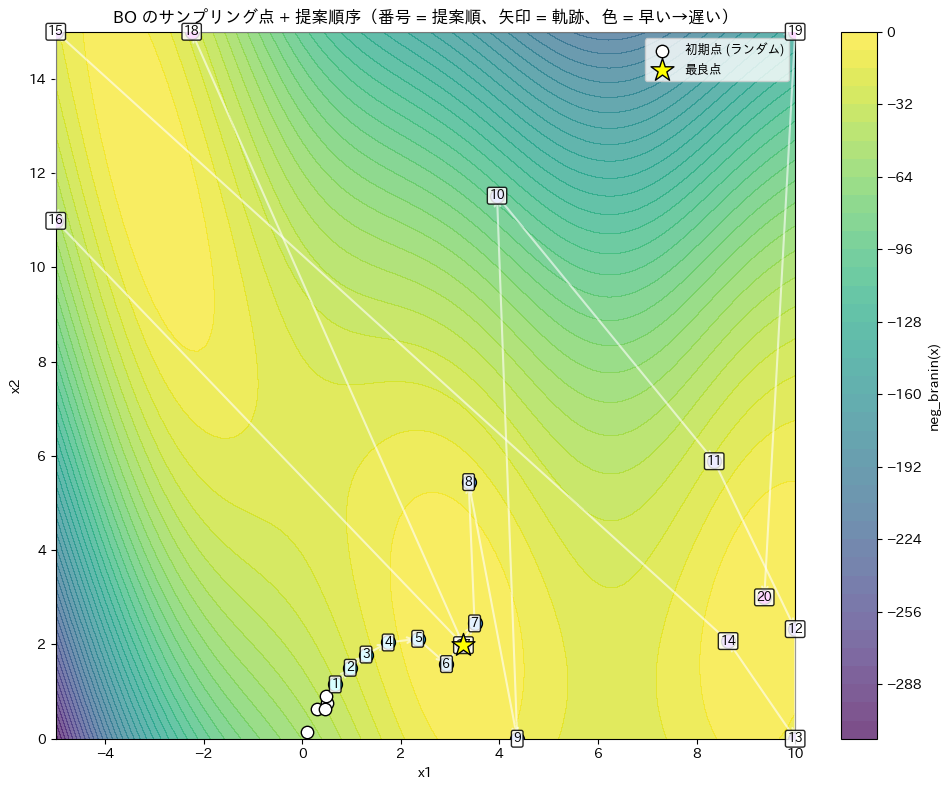

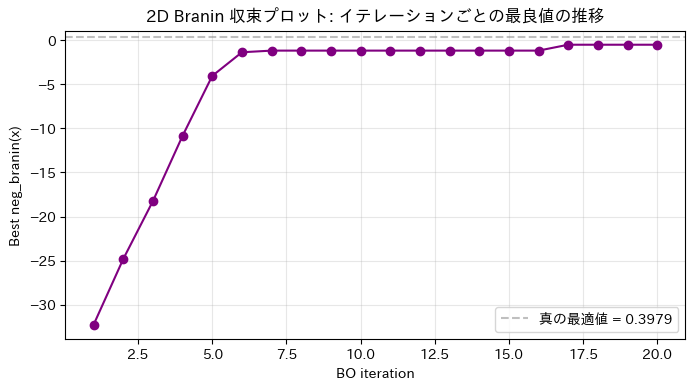

In [27]:
# サンプリング点 + 順序 + 軌跡を地形図に重ねて表示
fig, ax = plt.subplots(figsize=(10, 8))
n_initial = 5

# 地形図（Branin の実際の探索範囲）
cont = ax.contourf(X1.numpy(), X2.numpy(), Y_grid.numpy(), levels=50, cmap="viridis", alpha=0.7)
plt.colorbar(cont, ax=ax, label="neg_branin(x)")

# 初期点（白）
ax.scatter(train_X_2d[:n_initial, 0], train_X_2d[:n_initial, 1],
           c="white", edgecolors="black", s=80, label="初期点 (ランダム)", zorder=4)

# BO 提案点（番号付き + 色でイテレーションを表現）
bo_X = train_X_2d[n_initial:]
colors = plt.cm.cool(np.linspace(0, 1, len(bo_X)))
for i in range(len(bo_X)):
    ax.scatter(bo_X[i, 0], bo_X[i, 1], c=[colors[i]], edgecolors="black",
               s=100, zorder=5)
    ax.annotate(str(i + 1), (bo_X[i, 0].item(), bo_X[i, 1].item()),
                fontsize=9, ha="center", va="center", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85),
                zorder=6)

# 提案順に矢印で軌跡を描画
for i in range(len(bo_X) - 1):
    ax.annotate("", xy=(bo_X[i+1, 0].item(), bo_X[i+1, 1].item()),
                xytext=(bo_X[i, 0].item(), bo_X[i, 1].item()),
                arrowprops=dict(arrowstyle="->", color="white", alpha=0.6, lw=1.5),
                zorder=3)

# 最良点（星）
ax.scatter(train_X_2d[best_idx, 0], train_X_2d[best_idx, 1],
           c="yellow", edgecolors="black", s=300, marker="*", label="最良点", zorder=7)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("BO のサンプリング点 + 提案順序（番号 = 提案順、矢印 = 軌跡、色 = 早い→遅い）")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 収束プロット: iteration vs best neg_branin(x)
best_values_2d = [h["best_so_far"] for h in history_2d]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(best_values_2d) + 1), best_values_2d, "o-", color="purple")
plt.axhline(-branin.optimal_value, color="gray", linestyle="--", alpha=0.5,
            label=f"真の最適値 = {-branin.optimal_value:.4f}")
plt.xlabel("BO iteration")
plt.ylabel("Best neg_branin(x)")
plt.title("2D Branin 収束プロット: イテレーションごとの最良値の推移")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## まとめ

### 学んだこと

| コンポーネント | BoTorch での実装 | 役割 |
|---|---|---|
| **サロゲートモデル** | `SingleTaskGP` | 観測データから f(x) を近似。予測値 + 不確実性 |
| **モデル学習** | `fit_gpytorch_mll` | カーネルハイパーパラメータの最適化 |
| **獲得関数** | `ExpectedImprovement` | 次の候補点を選ぶ（探索 vs 活用のバランス） |
| **獲得関数最適化** | `optimize_acqf` | 獲得関数を最大化する x を見つける |

### Step 2 への接続

- 目的関数が1つ → **複数**になる（MOBO）
- `ExpectedImprovement` → **`qNEHVI`**（パレートフロント超体積の改善）
- パレートフロント の概念が登場